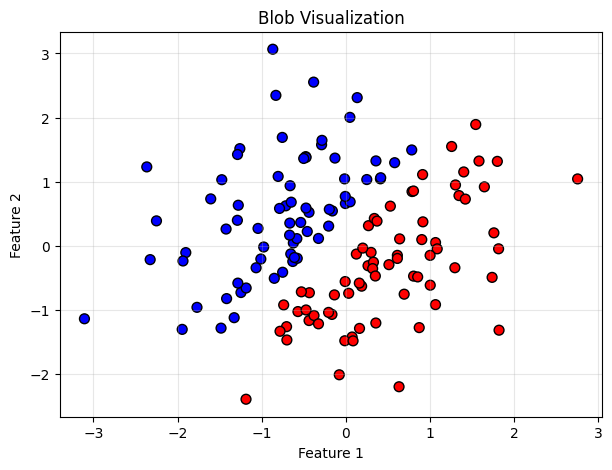

In [ ]:
# creating a usefull dataset is itself not relevant for understanding the perceptron update rule 

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
X = rng.normal(0, 1, size=(140, 2))

# Ground-truth separator with non-zero bias (challenging but still separable)
true_w = np.array([1.0, -0.8])
true_b = 0.2
margin = X @ true_w + true_b
normal = true_w / np.linalg.norm(true_w)

# Push points near the boundary slightly away from it to keep strict separability
eps = 0.2
mask = np.abs(margin) < eps
shift = (eps - np.abs(margin[mask]) + 1e-3)[:, None] * np.sign(margin[mask])[:, None] * normal
X[mask] += shift

y = np.where(X @ true_w + true_b >= 0, 1, -1)


plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", s=50, edgecolor="k")
plt.title("Blob Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from numpy import dot
# the algorithm itself


def update(data, y):
    w = np.zeros(data.shape[1]) # 1. start with w set to 0
    b = 0.0 # optionally bias b 0
    
    while True:
        updates = False
        for x, y_i  in zip(data, y): # for every datapoint do:

            if y_i * (dot(x, w) + b) <= 0: # check update condiction
                updates = True
                w += y_i * x # update w if prediction wrong
                b += y_i

        if not updates: # once there are no update anymore return learned parameters w and bias b
            return w, b
        

In [56]:
w, b = update(X, y)
print("w:", w)
print("b:", b)

w: [ 3.39441449 -2.55040592]
b: 1.0


In [ ]:
# update algorithm with histroy for visualizing progress
def update_with_history(data, y):
    w = np.zeros(data.shape[1])
    history = []

    while True:
        updates = 0
        for x, y_i in zip(data, y):
            if y_i * dot(x, w) <= 0:
                w += y_i * x
                updates += 1

        history.append((w.copy(), updates))
        if updates == 0:
            return w, history


w_final, history = update_with_history(X, y)
print(f"Converged in {len(history)} epochs")
print(f"Final w: {w_final}")

Converged in 19 epochs
Final w: [ 7.64937893 -6.11194107]


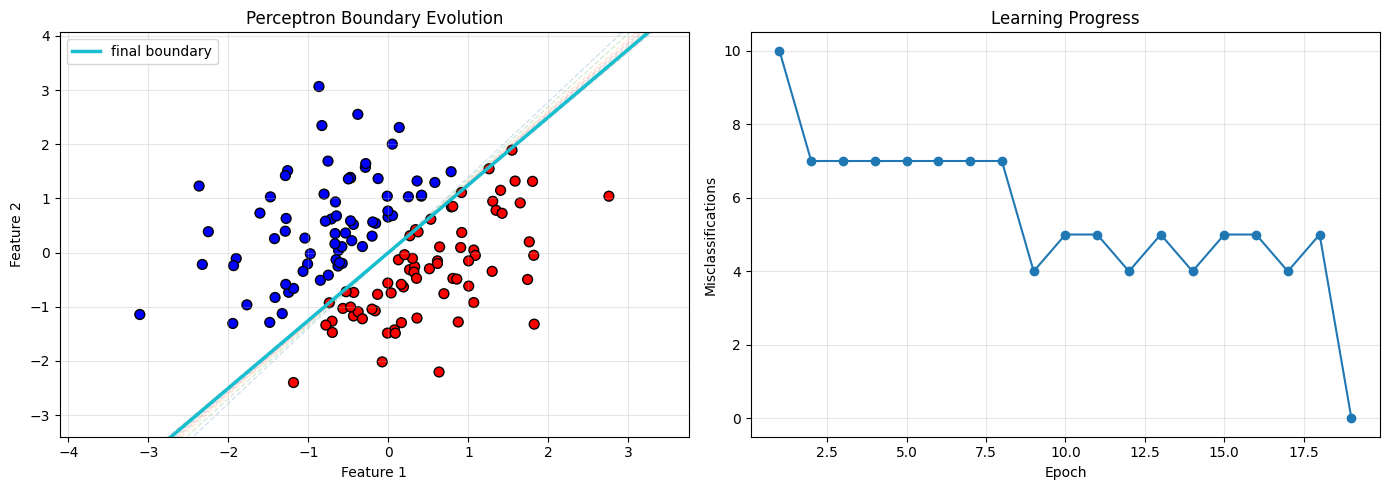

In [62]:
# visualize algorithm and output 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: data + decision boundary evolution
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", s=50, edgecolor="k")
axes[0].set_title("Perceptron Boundary Evolution")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].grid(True, alpha=0.3)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)

def plot_line(ax, w, style="-", alpha=1.0, lw=2, label=None):
    xs = np.linspace(x_min, x_max, 200)
    if abs(w[1]) < 1e-12:
        if abs(w[0]) > 1e-12:
            ax.axvline(0, linestyle=style, alpha=alpha, linewidth=lw, label=label)
        return
    ys = -(w[0] * xs) / w[1]
    ax.plot(xs, ys, style, alpha=alpha, linewidth=lw, label=label)

step = max(1, len(history) // 8)
for i, (w_i, _) in enumerate(history[:-1]):
    if i % step == 0:
        plot_line(axes[0], w_i, style="--", alpha=0.2, lw=1)

plot_line(axes[0], history[-1][0], style="-", alpha=1.0, lw=2.5, label="final boundary")
axes[0].legend()

# Right: number of misclassifications per epoch
mistakes = [m for _, m in history]
axes[1].plot(range(1, len(mistakes) + 1), mistakes, marker="o")
axes[1].set_title("Learning Progress")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Misclassifications")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()